##### ***池化层 pooling layer***
###### 由于卷积层对位置信息过于敏感，当位置信息有轻微的变动时，卷积层的输出也会有较大的变动。为了减少这种变动，引入了池化层。同时，为了降低空间分辨率，让模型对全局特征更加敏感，通过池化层可以实现这一目标。
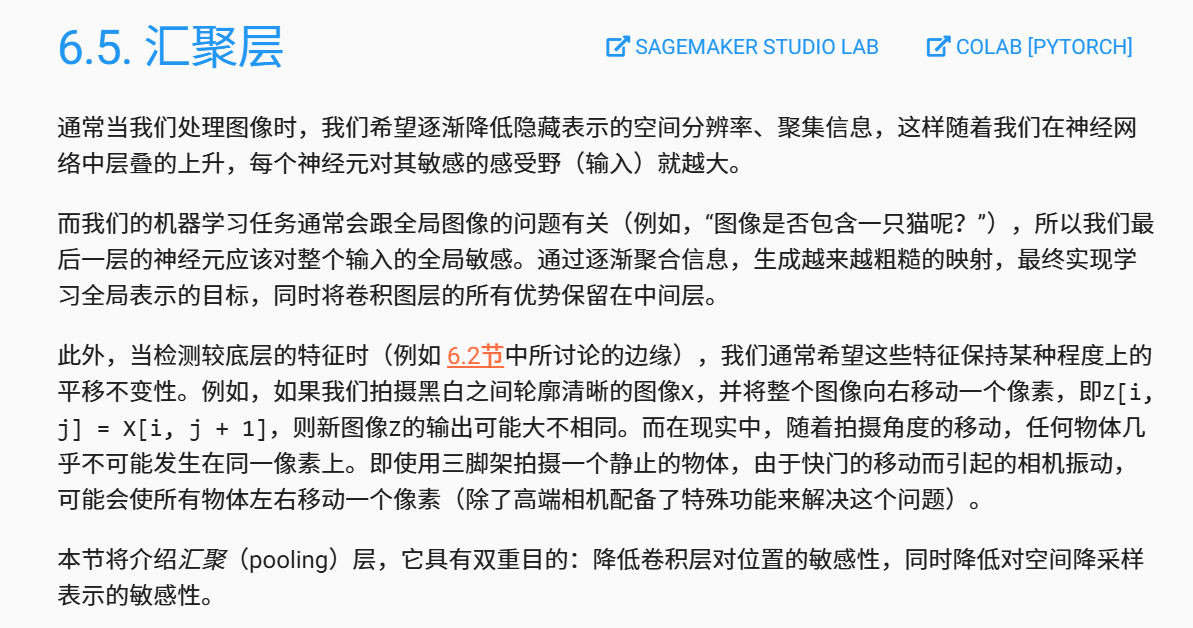
##### ***最大池化层 max pooling layer***
###### 最大池化层是池化层中最常用的一种。它的工作原理是将输入的特征图分成多个小的区域，每个区域内取最大值作为输出。相比于卷积核其实就是没有进行卷积操作而是找出其中的最大值
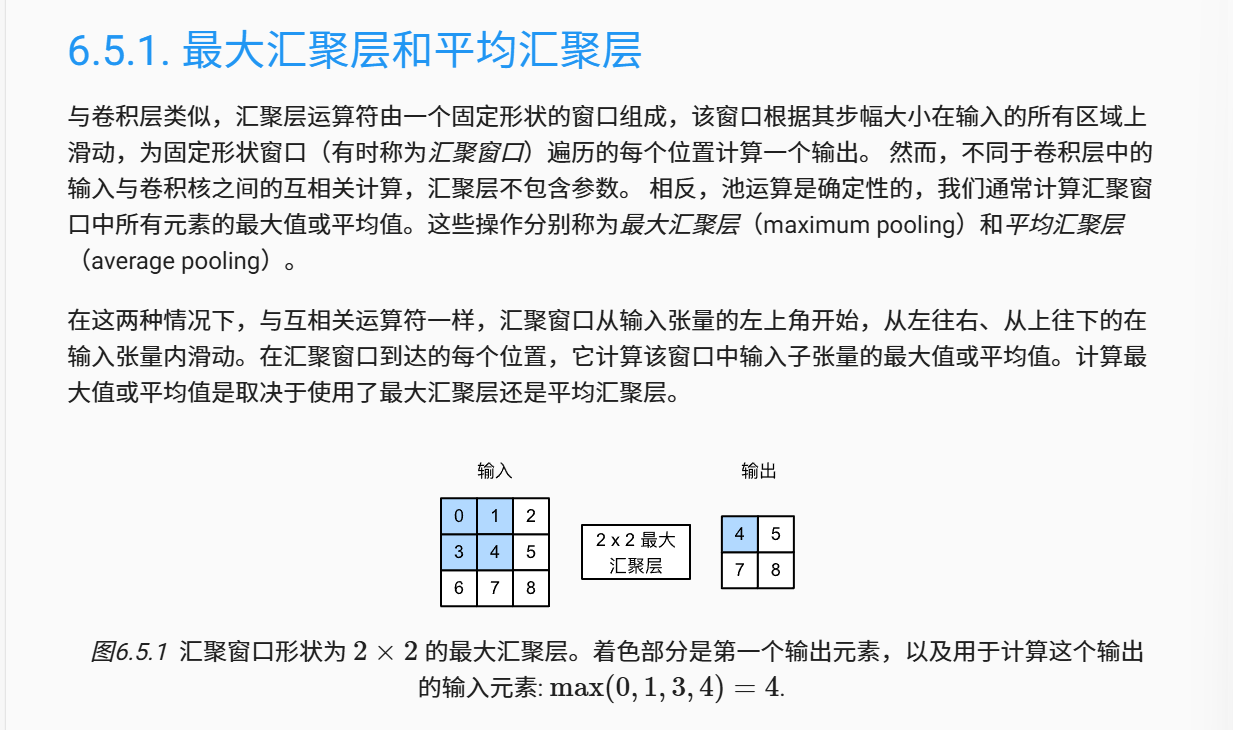
##### ***平均池化层 average pooling layer***
###### 平均池化层的工作原理与最大池化层类似，只是取的是区域内的平均值作为输出。
##### ***池化层的参数***
###### 池化层的参数和卷积层类似，都有填充和步幅，但是没有可以学习的参数，简单理解就是仅仅只是一个窗口，并没有数值。池化窗口大小指的是在输入特征图上滑动的窗口大小，通常是一个正方形或矩形。步长指的是窗口在输入特征图上滑动的距离。
###### 在每个输入通道上会独立的进行池化操作得到对应的输出通道，因此池化层的输出通道数与输入通道数相同。
###### **池化层一般放在卷积层之后，用于减少特征图的空间分辨率，同时提取特征图的全局信息。**

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

def pool2d(X, pool_size, mode='max'):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] - p_h + 1, X.shape[1] - p_w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == 'max':
                Y[i, j] = X[i:i+p_h, j:j+p_w].max()
            elif mode == 'avg':
                Y[i, j] = X[i:i+p_h, j:j+p_w].mean()
    return Y

In [2]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))

tensor([[4., 5.],
        [7., 8.]])

In [3]:
pool2d(X, (2, 2), 'avg')


tensor([[2., 3.],
        [5., 6.]])

In [4]:
# pytorch 中的池化层
X = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4))
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

In [5]:
# 默认情况下，深度学习框架中的步幅和池化窗口大小是一致的，因此如果我们使用形状为（3， 3）的池化窗口，那么默认情况下，我们得到的步幅形状为（3， 3）。
pool2d = nn.MaxPool2d(3)
pool2d(X)

tensor([[[[10.]]]])

In [6]:
# 填充和步幅也可以手动设定
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

In [8]:
# 也可以设定任意大小的窗口，并任意分配填充和步幅
pool2d = nn.MaxPool2d((2, 3), padding=(0, 1), stride=(2, 3))
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

In [9]:
# 对于多输入通道，池化层对每个输入通道分别进行池化，而不是像卷积层那样将通道维度上的向量拼接在一起。
X = torch.cat((X, X+1), dim=1)
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])

In [10]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]],

         [[ 6.,  8.],
          [14., 16.]]]])